In [1]:
import torch
import os

# Check available CUDA devices
n_gpus = torch.cuda.device_count()
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"GPU Count: {n_gpus}")

if n_gpus >= 2:
    print(f"Device 0: {torch.cuda.get_device_name(0)}")
    print(f"Device 1: {torch.cuda.get_device_name(1)}")
    print("Dual T4 GPUs detected and ready!")
else:
    print("Warning: Dual GPU not detected. Ensure Notebook settings -> Accelerator is set to 'GPU T4 x 2'")

CUDA Available: False
GPU Count: 0


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [3]:


df = pd.read_csv('/kaggle/input/datasets/shayanazmi05/customer-churn/customer_churn.csv')  # update path to your dataset location
print(df.shape)
df.head()

(12055, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,$29.85,$29.85,No
1,Male,0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed Check,$56.95,$1889.5,NO
2,Male,0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,$53.85,$108.15,YES
3,Male,0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,bank transfer (automatic),$42.3,$1840.75,No
4,Female,0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,ELECTRONIC CHECK,$70.7,$nan,yes


In [4]:
# Normalize all string/object columns: strip whitespace, standardize case
str_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
for c in str_cols:
    df[c] = df[c].astype(str).str.strip()

# Target cleanup: collapse 8 raw variants into clean binary
df['Churn'] = df['Churn'].str.lower().map({'no': 0, 'yes': 1})
print(df['Churn'].value_counts(dropna=False))

# Consolidate PaymentMethod casing variants
df['PaymentMethod'] = df['PaymentMethod'].str.lower().str.strip()
print(df['PaymentMethod'].value_counts())

# Normalize remaining binary/categorical string cols to consistent case
binary_like = ['gender','Partner','Dependents','PhoneService','MultipleLines',
               'InternetService','OnlineSecurity','OnlineBackup','DeviceProtection',
               'TechSupport','StreamingTV','StreamingMovies','Contract','PaperlessBilling']
for c in binary_like:
    df[c] = df[c].str.strip().str.title()

Churn
0    8650
1    3405
Name: count, dtype: int64
PaymentMethod
electronic check             4145
credit card (automatic)      2930
mailed check                 2585
bank transfer (automatic)    2395
Name: count, dtype: int64


In [5]:
def clean_currency(series):
    s = series.astype(str).str.replace(r'[£$]', '', regex=True).str.strip()
    s = s.replace({'nan': np.nan, 'NaN': np.nan, '': np.nan})
    return pd.to_numeric(s, errors='coerce')

df['MonthlyCharges'] = clean_currency(df['MonthlyCharges'])
df['TotalCharges'] = clean_currency(df['TotalCharges'])

print("MonthlyCharges nulls:", df['MonthlyCharges'].isnull().sum())
print("TotalCharges nulls:", df['TotalCharges'].isnull().sum())

MonthlyCharges nulls: 301
TotalCharges nulls: 1205


In [6]:
# Negative tenure is physically impossible -> take absolute value (data entry sign bug)
print("Negative tenure rows before fix:", (df['tenure'] < 0).sum())
df['tenure'] = df['tenure'].abs()

# Flag missingness before imputing (may carry signal)
df['tenure_was_missing'] = df['tenure'].isnull().astype(int)

# Drop exact duplicate rows
before = df.shape[0]
df = df.drop_duplicates()
print(f"Dropped {before - df.shape[0]} duplicate rows")

Negative tenure rows before fix: 127
Dropped 27 duplicate rows


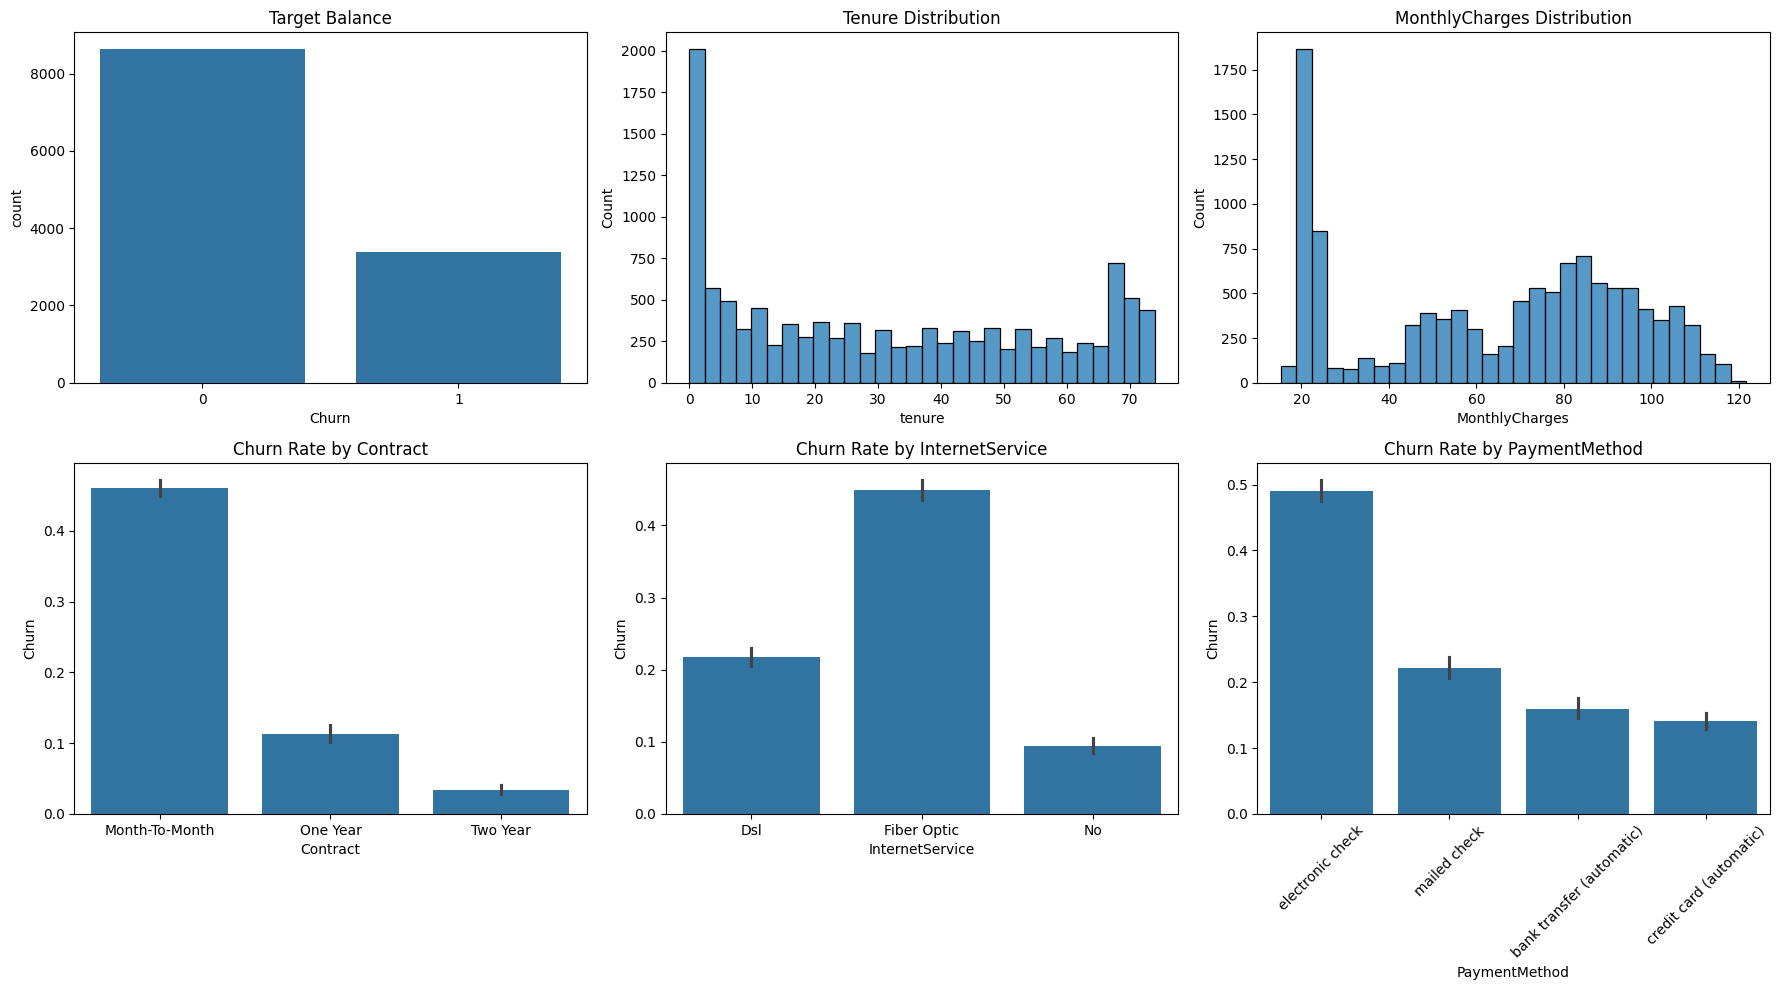

tenure           -0.358265
MonthlyCharges    0.187945
TotalCharges     -0.213222
Churn             1.000000
Name: Churn, dtype: float64


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.countplot(x='Churn', data=df, ax=axes[0,0])
axes[0,0].set_title('Target Balance')

sns.histplot(df['tenure'].dropna(), bins=30, ax=axes[0,1])
axes[0,1].set_title('Tenure Distribution')

sns.histplot(df['MonthlyCharges'].dropna(), bins=30, ax=axes[0,2])
axes[0,2].set_title('MonthlyCharges Distribution')

sns.barplot(x='Contract', y='Churn', data=df, ax=axes[1,0])
axes[1,0].set_title('Churn Rate by Contract')

sns.barplot(x='InternetService', y='Churn', data=df, ax=axes[1,1])
axes[1,1].set_title('Churn Rate by InternetService')

sns.barplot(x='PaymentMethod', y='Churn', data=df, ax=axes[1,2])
axes[1,2].set_title('Churn Rate by PaymentMethod')
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Correlation of numerics with target
print(df[['tenure','MonthlyCharges','TotalCharges','Churn']].corr()['Churn'])

In [8]:
df['expected_total'] = df['tenure'] * df['MonthlyCharges']
df['total_charges_deviation'] = (df['TotalCharges'] - df['expected_total']).abs()

print(df['total_charges_deviation'].describe())
# Large deviations = proration/fees/credits per problem statement; small = consistent billing

count    10024.000000
mean       549.124163
std       1026.629402
min          0.000000
25%         20.450000
50%         73.350000
75%        582.710000
max       7061.730000
Name: total_charges_deviation, dtype: float64


In [9]:
# Service bundle depth: count of "Yes" add-on services
addon_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection',
              'TechSupport','StreamingTV','StreamingMovies']
df['num_addon_services'] = (df[addon_cols] == 'Yes').sum(axis=1)

# Tenure buckets
df['tenure_bucket'] = pd.cut(df['tenure'], bins=[-1,12,24,48,100],
                              labels=['0-12','13-24','25-48','49+'])

# Avg monthly spend (guard against div-by-zero)
df['avg_monthly_spend'] = np.where(df['tenure'] > 0,
                                    df['TotalCharges'] / df['tenure'],
                                    df['MonthlyCharges'])

In [10]:


target = 'Churn'
drop_cols = ['expected_total', 'total_charges_deviation']  # diagnostic-only, not features
X = df.drop(columns=[target] + drop_cols)
y = df[target]

numeric_features = ['tenure','MonthlyCharges','TotalCharges','num_addon_services','avg_monthly_spend']
categorical_features = [c for c in X.columns if c not in numeric_features]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))

(9622, 23) (2406, 23)
Churn
0    0.717834
1    0.282166
Name: proportion, dtype: float64


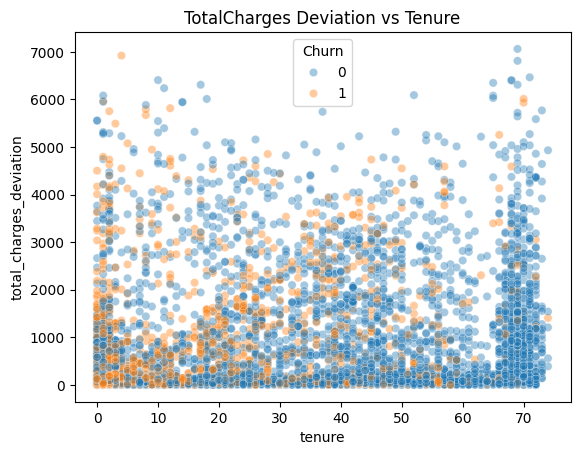

,tenure,MonthlyCharges,TotalCharges,expected_total,total_charges_deviation
8053,69.0,115.43,902.94,7964.67,7061.73
8532,4.0,84.70,7260.44,338.80,6921.64
8982,69.0,23.36,8422.90,1611.84,6811.06
10305,71.0,111.94,1482.30,7947.74,6465.44
11838,10.0,99.49,7401.45,994.90,6406.55
9480,68.0,22.50,7932.66,1530.00,6402.66
8312,68.0,109.95,1075.45,7476.60,6401.15
10442,65.0,111.26,883.19,7231.90,6348.71
11435,69.0,24.29,7985.76,1676.01,6309.75
7255,17.0,93.82,7903.84,1594.94,6308.90


In [11]:
# Is deviation driven by high-tenure customers (rate changed over time) or random noise?
sns.scatterplot(x='tenure', y='total_charges_deviation', hue='Churn', data=df, alpha=0.4)
plt.title('TotalCharges Deviation vs Tenure')
plt.show()

# Top 10 worst offenders — inspect manually
df.nlargest(10, 'total_charges_deviation')[['tenure','MonthlyCharges','TotalCharges','expected_total','total_charges_deviation']]

In [12]:
# Flag severely inconsistent TotalCharges as unreliable rather than trusting them blindly
# Use a threshold - anything where deviation exceeds a few months of MonthlyCharges is implausible
df['total_charges_plausible'] = df['total_charges_deviation'] <= (df['MonthlyCharges'] * 3).fillna(0)
print(df['total_charges_plausible'].value_counts(normalize=True))
print("\nChurn rate for implausible rows:", df.loc[~df['total_charges_plausible'], 'Churn'].mean())
print("Churn rate for plausible rows:", df.loc[df['total_charges_plausible'], 'Churn'].mean())

total_charges_plausible
True     0.534835
False    0.465165
Name: proportion, dtype: float64

Churn rate for implausible rows: 0.26309204647006257
Churn rate for plausible rows: 0.2987719570962226


In [13]:
# Recommended: don't trust raw TotalCharges as a feature at all where implausible.
# Replace it with the more reliable derived value for those rows.
df['TotalCharges_clean'] = np.where(
    df['total_charges_plausible'],
    df['TotalCharges'],
    df['expected_total']   # fall back to tenure * MonthlyCharges when TotalCharges looks corrupted
)

In [14]:
# Flag implausible TotalCharges and create the cleaned version
df['total_charges_plausible'] = df['total_charges_deviation'] <= (df['MonthlyCharges'] * 3).fillna(0)
print(df['total_charges_plausible'].value_counts(normalize=True))
print("\nChurn rate - implausible rows:", df.loc[~df['total_charges_plausible'], 'Churn'].mean())
print("Churn rate - plausible rows:", df.loc[df['total_charges_plausible'], 'Churn'].mean())

df['TotalCharges_clean'] = np.where(
    df['total_charges_plausible'],
    df['TotalCharges'],
    df['expected_total']
)

# Rebuild X/y with the cleaned column, drop diagnostic-only columns
target = 'Churn'
drop_cols = ['expected_total', 'total_charges_deviation', 'total_charges_plausible', 'TotalCharges']
X = df.drop(columns=[target] + drop_cols)
y = df[target]

numeric_features = ['tenure','MonthlyCharges','TotalCharges_clean','num_addon_services','avg_monthly_spend']
categorical_features = [c for c in X.columns if c not in numeric_features]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

total_charges_plausible
True     0.534835
False    0.465165
Name: proportion, dtype: float64

Churn rate - implausible rows: 0.26309204647006257
Churn rate - plausible rows: 0.2987719570962226
(9622, 23) (2406, 23)


In [15]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Handle class imbalance (71.8/28.2) via scale_pos_weight
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

# Tuned via RandomizedSearchCV (Cell 14c) - best CV params
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.7,
    colsample_bytree=0.8,       # not searched, kept from baseline
    min_child_weight=5,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb_model)
])

clf_pipeline.fit(X_train, y_train)

scale_pos_weight: 2.5440147329650094


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges_clean',
                                                   'num_addon_services',
                                                   'avg_monthly_spend']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncode...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.03,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None, min_child_weight=5,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=200, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [16]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(clf_pipeline, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f"CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print("Fold scores:", np.round(cv_scores, 4))

CV ROC-AUC: 0.8534 ± 0.0053
Fold scores: [0.852  0.86   0.8593 0.8484 0.8472]


# **Logistic regression**

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])
logreg_pipeline.fit(X_train, y_train)

logreg_probs = logreg_pipeline.predict_proba(X_test)[:, 1]
print("Logistic Regression ROC-AUC:", roc_auc_score(y_test, logreg_probs))

Logistic Regression ROC-AUC: 0.852510120387197


# **Evaluate XGBoost: ROC-AUC, classification report, confusion matrix**

XGBoost ROC-AUC: 0.8557012296259785

               precision    recall  f1-score   support

           0       0.90      0.77      0.83      1727
           1       0.57      0.79      0.66       679

    accuracy                           0.77      2406
   macro avg       0.74      0.78      0.74      2406
weighted avg       0.81      0.77      0.78      2406



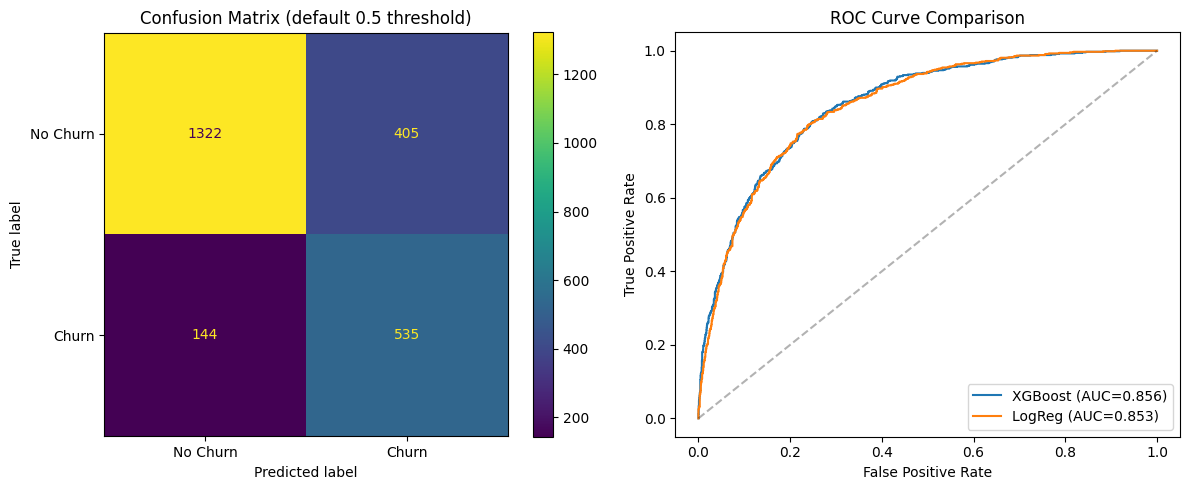

In [18]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve

xgb_probs = clf_pipeline.predict_proba(X_test)[:, 1]
xgb_preds = clf_pipeline.predict(X_test)

print("XGBoost ROC-AUC:", roc_auc_score(y_test, xgb_probs))
print("\n", classification_report(y_test, xgb_preds))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, xgb_preds)
ConfusionMatrixDisplay(cm, display_labels=['No Churn','Churn']).plot(ax=axes[0])
axes[0].set_title('Confusion Matrix (default 0.5 threshold)')

fpr, tpr, _ = roc_curve(y_test, xgb_probs)
axes[1].plot(fpr, tpr, label=f'XGBoost (AUC={roc_auc_score(y_test, xgb_probs):.3f})')
fpr_lr, tpr_lr, _ = roc_curve(y_test, logreg_probs)
axes[1].plot(fpr_lr, tpr_lr, label=f'LogReg (AUC={roc_auc_score(y_test, logreg_probs):.3f})')
axes[1].plot([0,1],[0,1],'k--', alpha=0.3)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve Comparison')
axes[1].legend()

plt.tight_layout()
plt.show()

# **Threshold tuning (since false negatives cost more than false positives in churn)**

Best threshold by F1: 0.505 (F1=0.663)


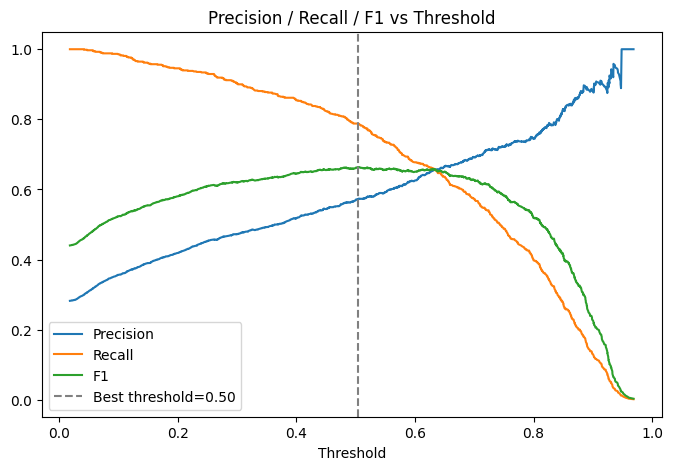

              precision    recall  f1-score   support

           0       0.90      0.77      0.83      1727
           1       0.57      0.79      0.66       679

    accuracy                           0.77      2406
   macro avg       0.74      0.78      0.75      2406
weighted avg       0.81      0.77      0.78      2406



In [19]:
from sklearn.metrics import precision_recall_curve, f1_score

precisions, recalls, thresholds = precision_recall_curve(y_test, xgb_probs)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best threshold by F1: {best_threshold:.3f} (F1={f1_scores[best_idx]:.3f})")

plt.figure(figsize=(8,5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.plot(thresholds, f1_scores[:-1], label='F1')
plt.axvline(best_threshold, color='gray', linestyle='--', label=f'Best threshold={best_threshold:.2f}')
plt.xlabel('Threshold')
plt.legend()
plt.title('Precision / Recall / F1 vs Threshold')
plt.show()

# Apply tuned threshold
xgb_preds_tuned = (xgb_probs >= best_threshold).astype(int)
print(classification_report(y_test, xgb_preds_tuned))

# **SHAP explainability (business-facing "why does the model think this customer will churn")**

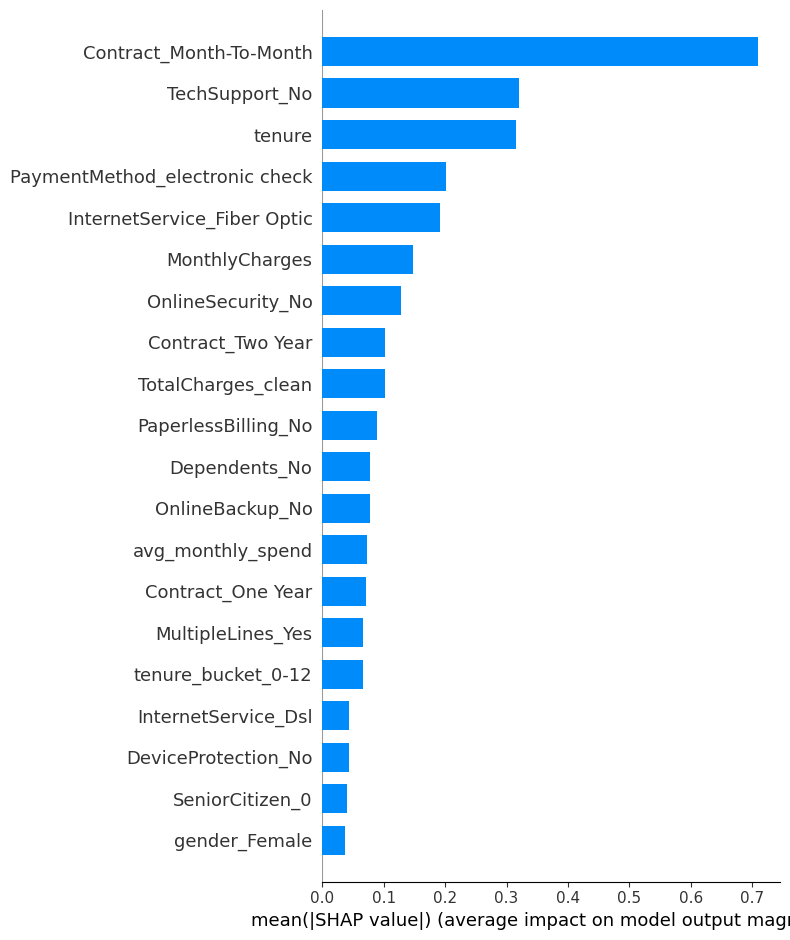

In [20]:
import shap

# Get feature names post-preprocessing
ohe = clf_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_feature_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_feature_names)

X_test_transformed = clf_pipeline.named_steps['preprocessor'].transform(X_test)
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

explainer = shap.TreeExplainer(clf_pipeline.named_steps['model'])
shap_values = explainer.shap_values(X_test_transformed)

# Global feature importance
shap.summary_plot(shap_values, X_test_transformed, feature_names=all_feature_names, plot_type='bar', show=True)

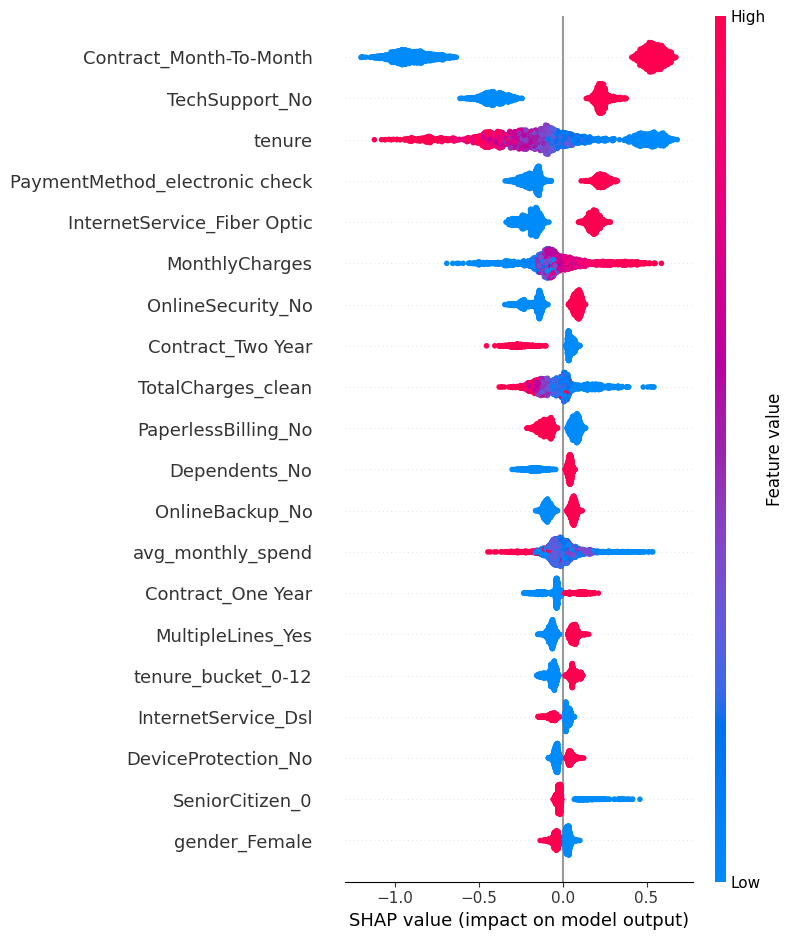

In [21]:
shap.summary_plot(shap_values, X_test_transformed, feature_names=all_feature_names, show=True)

# **Explain a single at-risk customer (for the business use case: "why is this specific customer flagged?")**

Customer churn probability: 0.969


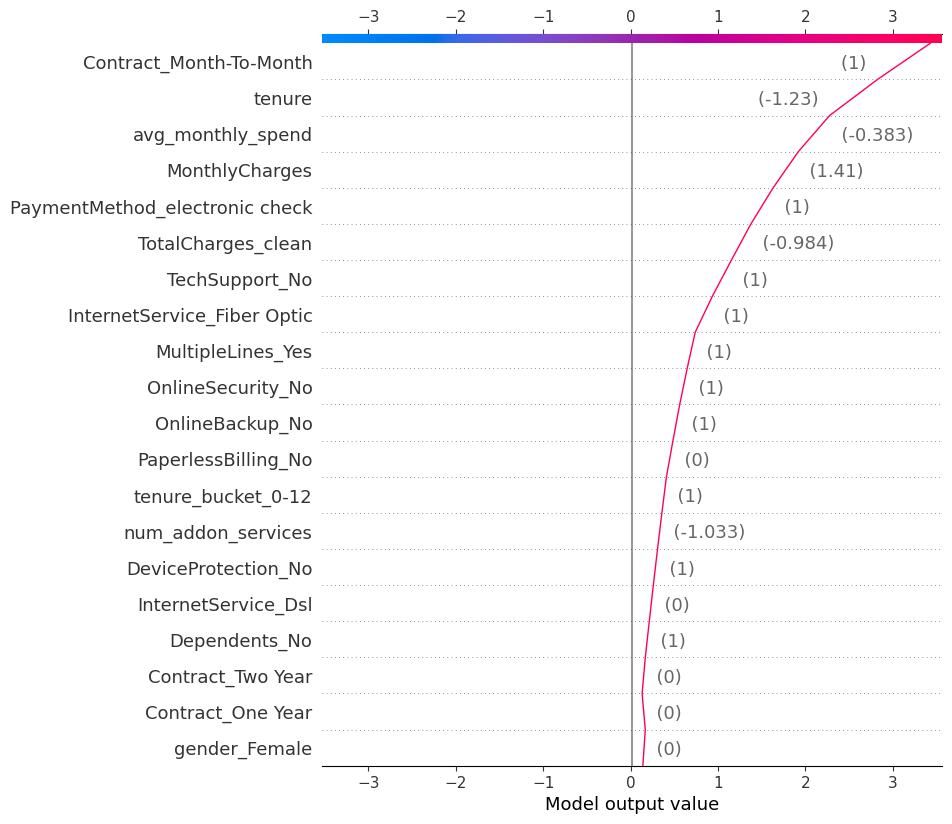

In [22]:
# Pick a customer the model scored as high-risk
high_risk_idx = np.argmax(xgb_probs)
print(f"Customer churn probability: {xgb_probs[high_risk_idx]:.3f}")

shap.decision_plot(
    explainer.expected_value,
    shap_values[high_risk_idx],
    X_test_transformed[high_risk_idx],
    feature_names=all_feature_names
)


# **Feature importance table**

In [23]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False).head(15)

print(importance_df.to_string(index=False))

                       feature  mean_abs_shap
       Contract_Month-To-Month       0.709563
                TechSupport_No       0.320686
                        tenure       0.315993
PaymentMethod_electronic check       0.201282
   InternetService_Fiber Optic       0.190955
                MonthlyCharges       0.147861
             OnlineSecurity_No       0.128954
             Contract_Two Year       0.102179
            TotalCharges_clean       0.101574
           PaperlessBilling_No       0.089245
                 Dependents_No       0.077822
               OnlineBackup_No       0.077701
             avg_monthly_spend       0.073222
             Contract_One Year       0.070738
             MultipleLines_Yes       0.066965


In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = X_train[numeric_features].copy()
vif_data = vif_data.fillna(vif_data.median())
vif_df = pd.DataFrame({
    'feature': numeric_features,
    'VIF': [variance_inflation_factor(vif_data.values, i) for i in range(len(numeric_features))]
})
print(vif_df.sort_values('VIF', ascending=False))

              feature       VIF
2  TotalCharges_clean  8.587223
0              tenure  5.757763
3  num_addon_services  4.689033
1      MonthlyCharges  4.536898
4   avg_monthly_spend  1.210663


In [25]:
import joblib
joblib.dump(clf_pipeline, '/kaggle/working/churn_xgb_pipeline.pkl')
print("Model saved.")

Model saved.


Cost-optimal threshold: 0.26, total cost: $61,500


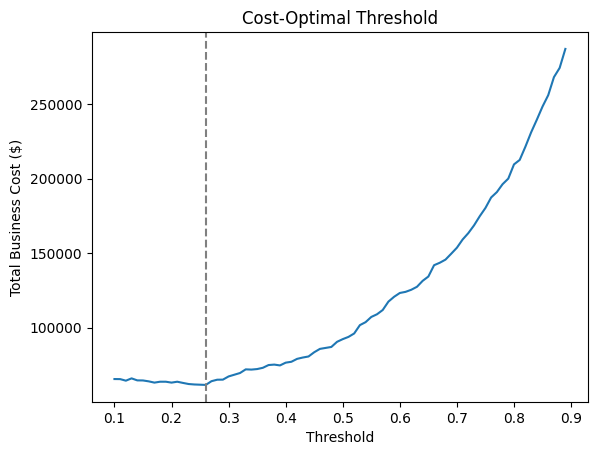

In [26]:
# Get business estimates for these two numbers before finalizing
cost_fn = 500   # est. $ cost of losing a customer (LTV)
cost_fp = 50    # est. $ cost of an unnecessary retention offer

xgb_probs = clf_pipeline.predict_proba(X_test)[:, 1]
thresholds_test = np.arange(0.1, 0.9, 0.01)
costs = []
for t in thresholds_test:
    preds = (xgb_probs >= t).astype(int)
    fn = ((preds == 0) & (y_test == 1)).sum()
    fp = ((preds == 1) & (y_test == 0)).sum()
    costs.append(fn * cost_fn + fp * cost_fp)

best_cost_threshold = thresholds_test[np.argmin(costs)]
print(f"Cost-optimal threshold: {best_cost_threshold:.2f}, total cost: ${min(costs):,.0f}")

plt.plot(thresholds_test, costs)
plt.axvline(best_cost_threshold, color='gray', linestyle='--')
plt.xlabel('Threshold'); plt.ylabel('Total Business Cost ($)')
plt.title('Cost-Optimal Threshold')
plt.show()

In [27]:
results = X_test.copy()
results['churn_probability'] = xgb_probs
results['risk_tier'] = pd.cut(xgb_probs, bins=[0, 0.3, 0.6, 1.0],
                                labels=['Low', 'Medium', 'High'])
results['actual_churn'] = y_test.values
results.sort_values('churn_probability', ascending=False).to_csv(
    '/kaggle/working/customer_risk_scores.csv', index=False
)
print(results['risk_tier'].value_counts())

risk_tier
Low       1109
High       735
Medium     562
Name: count, dtype: int64
